g# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from wandb.integration.metaflow import wandb_log

%matplotlib inline
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
df = pd.read_csv('tehranhouses.csv')
print(df.shape)
df.head()


(3479, 8)


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1850000000,61666.67
1,60,1,True,True,True,Shahran,1850000000,61666.67
2,79,2,True,True,True,Pardis,550000000,18333.33
3,95,2,True,True,True,Shahrake Qods,902500000,30083.33
4,123,2,True,True,True,Shahrake Gharb,7000000000,233333.33


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   str    
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   str    
 6   Price       3479 non-null   int64  
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(1), int64(2), str(2)
memory usage: 146.2 KB


In [4]:
df.isnull().sum()

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [5]:
print(df.describe())

         Room          Price  Price(USD)
count 3479.00        3479.00     3479.00
mean     2.08  5359022710.58   178634.09
std      0.76  8099934524.33   269997.82
min      0.00     3600000.00      120.00
25%      2.00  1418250000.00    47275.00
50%      2.00  2900000000.00    96666.67
75%      2.00  6000000000.00   200000.00
max      5.00 92400000000.00  3080000.00


In [6]:
df['Area'] = df['Area'].apply(lambda x: re.sub(',', '', x))
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')
df = df[df['Area'] < 2000]
df.shape

(3474, 8)

In [7]:
df.dropna(inplace=True)

In [8]:
df.shape

(3451, 8)

In [9]:
df['Price'].skew()

np.float64(4.767421140547335)

Text(0.5, 1.0, 'توزیع قیمت خام')

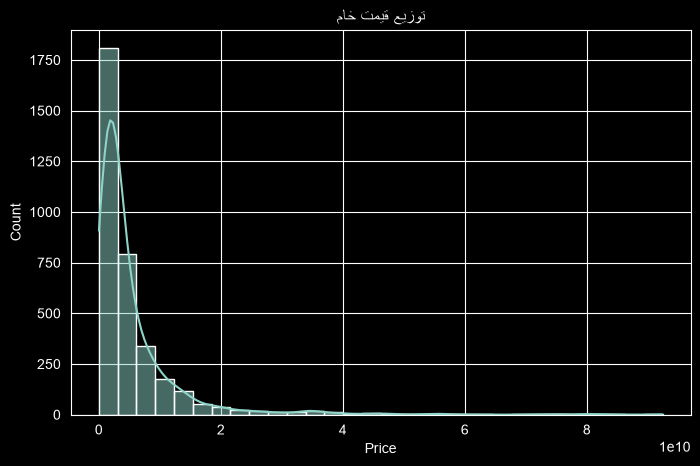

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('توزیع قیمت خام')

In [11]:
df['Price_log'] = np.log1p(df['Price'])
df['Price_log'].skew()

np.float64(0.05957208896627695)

Text(0.5, 1.0, 'توزیع قیمت بعد از log transform')

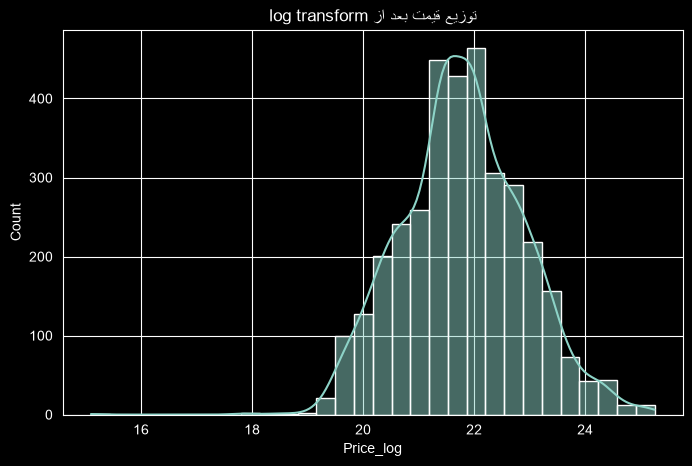

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price_log'], bins=30, kde=True)
plt.title('توزیع قیمت بعد از log transform')

In [13]:
boolean_features = ['Parking', 'Warehouse', 'Elevator']
df[boolean_features] = df[boolean_features].astype('int64')
print(df[boolean_features].head())

   Parking  Warehouse  Elevator
0        1          1         1
1        1          1         1
2        1          1         1
3        1          1         1
4        1          1         1


In [14]:
df['Address'].nunique()

192

In [15]:
df['Address'].value_counts().head(10)

Address
Punak                     161
Pardis                    146
West Ferdows Boulevard    145
Gheitarieh                140
Shahran                   130
Saadat Abad               129
Parand                    127
Shahr-e-Ziba              109
Southern Janatabad         93
Jeyhoon                    91
Name: count, dtype: int64

In [16]:
df['Address'].value_counts().tail(20)

Address
Ray - Pilgosh           1
Ghiyamdasht             1
Telecommunication       1
Mirza Shirazi           1
Gandhi                  1
Safadasht               1
Khademabad Garden       1
Hassan Abad             1
Boloorsazi              1
Mehrabad River River    1
Varamin - Beheshti      1
Thirteen November       1
Darakeh                 1
Aliabad South           1
Alborz Complex          1
Firoozkooh              1
Shadabad                1
Naziabad                1
Javadiyeh               1
Yakhchiabad             1
Name: count, dtype: int64

In [17]:
(df['Address'].value_counts() == 1).sum()

np.int64(42)

In [18]:
address_counts = df['Address'].value_counts()
rare_addresses = address_counts[address_counts < 5].index

df['Address'] = df['Address'].apply(lambda x: 'Other' if x in rare_addresses else x)
df['Address'].nunique()



99

In [19]:
df['Address'].nunique()

99

In [20]:
df_final = pd.get_dummies(df, columns=['Address'], drop_first=True)

In [21]:
df_final = df_final.drop(columns=['Price(USD)', 'Price'])
df_final.head()

,Area,Room,Parking,Warehouse,Elevator,Price_log,Address_Absard,Address_Afsarieh,Address_Air force,Address_Ajudaniye,...,Address_Tarasht,Address_Tehransar,Address_Tenant,Address_Valiasr,Address_Velenjak,Address_West Ferdows Boulevard,Address_West Pars,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh
0,63,1,1,1,1,21.34,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,60,1,1,1,1,21.34,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,79,2,1,1,1,20.13,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,95,2,1,1,1,20.62,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,123,2,1,1,1,22.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [22]:
X = df_final.drop(columns=['Price_log'])
y = df_final['Price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2760, 103) (691, 103) (2760,) (691,)


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.8804701258899827
RMSE: 0.3741251555913309
MAE: 0.2550833268307575


In [29]:
print(df[df['Area'] > 10000][['Area', 'Room', 'Address', 'Price']])

Empty DataFrame
Columns: [Area, Room, Address, Price]
Index: []


In [30]:
from sklearn.model_selection import GridSearchCV, KFold
import time

def parameter_finder(model, parameters):
    start = time.time()

    grid = GridSearchCV(model,
                        param_grid=parameters,
                        refit=True,
                        cv=KFold(shuffle=True, random_state=1),
                        n_jobs=-1)
    grid_fit = grid.fit(X_train, y_train)
    y_pred = grid_fit.predict(X_test)

    train_score = grid_fit.score(X_train, y_train)
    test_score = grid_fit.score(X_test, y_test)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

    model_name = str(model).split('(')[0]
    end = time.time()

    print(f"بهترین پارامترها برای {model_name}: {grid_fit.best_params_}")
    print(f"R2 روی train: {train_score:.4f}")
    print(f"R2 روی test: {test_score:.4f}")
    print(f"RMSE: {RMSE:.4f}")
    print(f"زمان اجرا: {end-start:.2f} ثانیه")

    return train_score, test_score, RMSE

In [31]:
from sklearn.linear_model import Ridge

ridge = Ridge(random_state=1)
param_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

ridge_train_score, ridge_test_score, ridge_RMSE = parameter_finder(ridge, param_ridge)

بهترین پارامترها برای Ridge: {'alpha': 0.1}
R2 روی train: 0.8650
R2 روی test: 0.8810
RMSE: 0.3734
زمان اجرا: 6.23 ثانیه


In [32]:
from sklearn.linear_model import Lasso

lasso = Lasso(random_state=1)
param_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

lasso_train_score, lasso_test_score, lasso_RMSE = parameter_finder(lasso, param_lasso)

بهترین پارامترها برای Lasso: {'alpha': 0.001}
R2 روی train: 0.8482
R2 روی test: 0.8713
RMSE: 0.3882
زمان اجرا: 0.38 ثانیه


In [33]:
from sklearn.linear_model import ElasticNet

eln = ElasticNet(random_state=1)
param_eln = {'alpha': [0.001, 0.01, 0.1, 1, 10],
            'l1_ratio': [0.3, 0.4, 0.5, 0.6, 0.7]}

eln_train_score, eln_test_score, eln_RMSE = parameter_finder(eln, param_eln)

بهترین پارامترها برای ElasticNet: {'alpha': 0.001, 'l1_ratio': 0.3}
R2 روی train: 0.8558
R2 روی test: 0.8797
RMSE: 0.3753
زمان اجرا: 3.35 ثانیه


In [34]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(random_state=1)
param_dtr = {'min_samples_split': [2, 3, 4, 5],
            'min_samples_leaf': [1, 2, 3]}

dtr_train_score, dtr_test_score, dtr_RMSE = parameter_finder(dtr, param_dtr)

بهترین پارامترها برای DecisionTreeRegressor: {'min_samples_leaf': 1, 'min_samples_split': 5}
R2 روی train: 0.9670
R2 روی test: 0.8167
RMSE: 0.4633
زمان اجرا: 0.77 ثانیه


In [35]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(random_state=1, n_jobs=-1)
param_rfr = {'min_samples_split': [2, 3, 4, 5],
            'min_samples_leaf': [1, 2, 3]}

rfr_train_score, rfr_test_score, rfr_RMSE = parameter_finder(rfr, param_rfr)

بهترین پارامترها برای RandomForestRegressor: {'min_samples_leaf': 1, 'min_samples_split': 5}
R2 روی train: 0.9518
R2 روی test: 0.8646
RMSE: 0.3982
زمان اجرا: 15.12 ثانیه


In [36]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_jobs=-1)
param_knr = {'n_neighbors': [5, 10, 15, 20],
            'weights': ['uniform', 'distance']}

knr_train_score, knr_test_score, knr_RMSE = parameter_finder(knr, param_knr)

بهترین پارامترها برای KNeighborsRegressor: {'n_neighbors': 5, 'weights': 'distance'}
R2 روی train: 0.9880
R2 روی test: 0.7411
RMSE: 0.5507
زمان اجرا: 1.27 ثانیه


In [39]:
from xgboost import XGBRegressor

xgboost = XGBRegressor(n_jobs=-1)
param_xgboost = {'n_estimators': [100, 300],
             'learning_rate': [0.1, 0.05],
             'subsample': [0.75],
             'colsample_bytree': [1],
             'max_depth': [3, 4, 5],
             'gamma': [0]}

xgboost_train_score, xgboost_test_score, xgboost_RMSE = parameter_finder(xgboost, param_xgboost)

بهترین پارامترها برای XGBRegressor: {'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.75}
R2 روی train: 0.9295
R2 روی test: 0.9060
RMSE: 0.3318
زمان اجرا: 8.02 ثانیه


In [38]:
!pip install xgboost

Looking in indexes: https://mirror-pypi.runflare.com/simple
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.8 MB/s eta 0:00:27
    --------------------------------------- 1.0/48.9 MB 1.8 MB/s eta 0:00:27
   - -------------------------------------- 1.3/48.9 MB 1.8 MB/s eta 0:00:27
   - -------------------------------------- 1.8/48.9 MB 1.8 MB/s eta 0:00:27
   - -------------------------------------- 2.1/48.9 MB 1.8 MB/s eta 0:00:27
   -- ------------------------------------- 2.6/48.9 MB 1.8 MB/s eta 0:00:26
   -- ------------------------------------- 2.9/48.9 MB 1.8 MB/s eta 0:00:26
   -- ------------------------------------- 3.4/48.9 MB 1.8 MB/s eta 0:00:26
   -- ------------------------------------- 3.7/48.9 MB 1.8 MB/s eta 0:00:26
   --- ------------------------------------ 3.9/48.9 MB 1.8 MB/s eta 0:00:25
   --- -----------------------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
models_score = pd.DataFrame({
    'Training R2': [lr_test_score if False else r2_score(y_train, lr.predict(X_train)),
                     ridge_train_score, lasso_train_score, eln_train_score,
                     dtr_train_score, rfr_train_score, knr_train_score, xgboost_train_score],
    'Testing R2': [r2_score(y_test, y_pred), ridge_test_score, lasso_test_score, eln_test_score,
                   dtr_test_score, rfr_test_score, knr_test_score, xgboost_test_score],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred)), ridge_RMSE, lasso_RMSE, eln_RMSE,
             dtr_RMSE, rfr_RMSE, knr_RMSE, xgboost_RMSE]
}, index=['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'DecisionTree',
          'RandomForest', 'KNN', 'XGBoost'])

models_score

,Training R2,Testing R2,RMSE
LinearRegression,0.87,0.88,0.37
Ridge,0.86,0.88,0.37
Lasso,0.85,0.87,0.39
ElasticNet,0.86,0.88,0.38
DecisionTree,0.97,0.82,0.46
RandomForest,0.95,0.86,0.40
KNN,0.99,0.74,0.55
XGBoost,0.93,0.91,0.33


In [43]:
print(models_score)

                  Training R2  Testing R2  RMSE
LinearRegression         0.87        0.88  0.37
Ridge                    0.86        0.88  0.37
Lasso                    0.85        0.87  0.39
ElasticNet               0.86        0.88  0.38
DecisionTree             0.97        0.82  0.46
RandomForest             0.95        0.86  0.40
KNN                      0.99        0.74  0.55
XGBoost                  0.93        0.91  0.33


C:\Users\novin\AppData\Local\Temp\ipykernel_1932\1344827979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(models_score.index), y=models_score['RMSE'], alpha=0.7, palette='Greens_r')


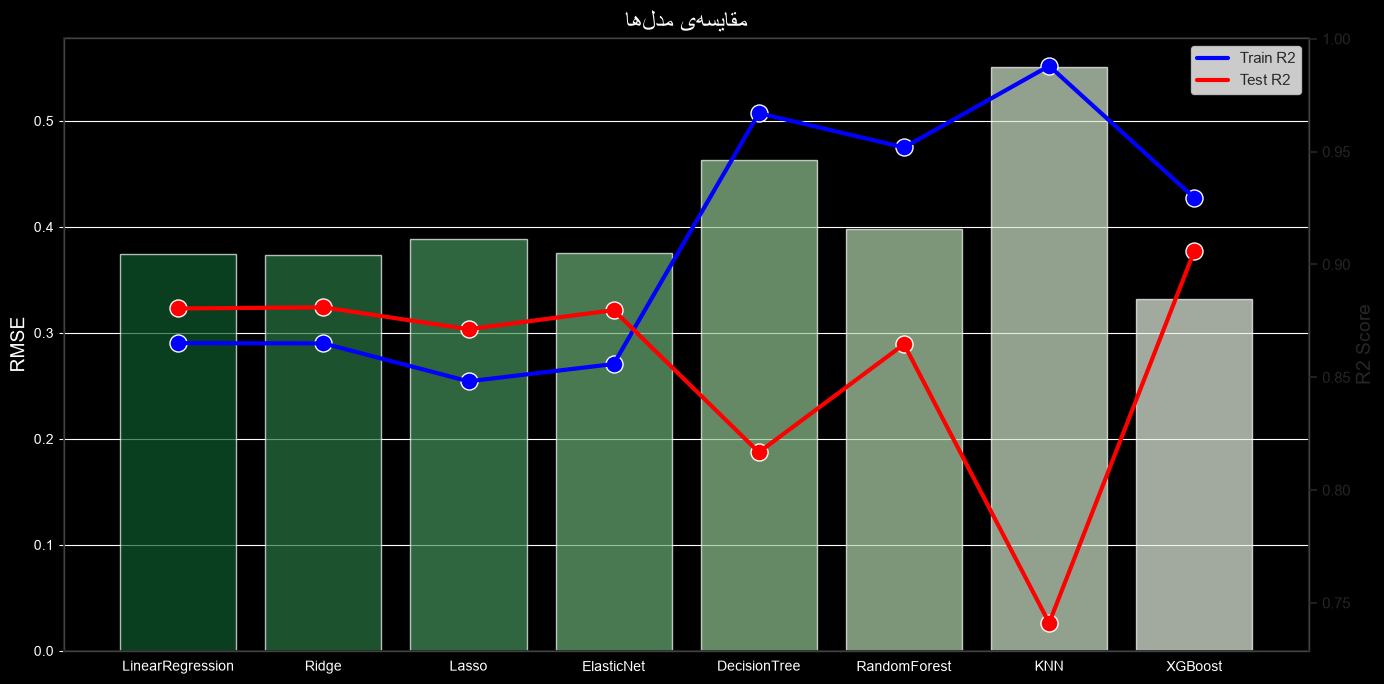

In [44]:
fig, ax = plt.subplots(figsize=(14,7))

sns.set(style='white')
ax.set_title("مقایسه‌ی مدل‌ها", fontsize=18)

ax = sns.barplot(x=list(models_score.index), y=models_score['RMSE'], alpha=0.7, palette='Greens_r')
ax.set_ylabel("RMSE", fontsize=14)

sec_ax = ax.twinx()
sec_ax = sns.lineplot(x=list(models_score.index), y=models_score['Training R2'], linewidth=3, color='blue', label='Train R2')
sec_ax = sns.scatterplot(x=list(models_score.index), y=models_score['Training R2'], s=150, color='blue')

sec_ax = sns.lineplot(x=list(models_score.index), y=models_score['Testing R2'], linewidth=3, color='red', label='Test R2')
sec_ax = sns.scatterplot(x=list(models_score.index), y=models_score['Testing R2'], s=150, color='red')

sec_ax.set_ylabel("R2 Score", fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [47]:
!pip install torch --index-url https://pypi.org/simple

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.1 MB 1.3 MB/s eta 0:01:35
   ---------------------------------------- 0.8/122.1 MB 1.4 MB/s eta 0:01:28
   ---------------------------------------- 1.0/122.1 MB 1.2 MB/s eta 0:01:42
   ---------------------------------------- 1.3/122.1 MB 1.2 MB/s eta 0:01:43
    --------------------------------------- 1.6/122.1 MB 1.2 MB/s eta 0:01:41
    --------------------------------------- 1.6/122.1 MB 1.2 MB/s eta 0:01:41
    --------------------------------------- 1.8/122.1 MB 1.2 MB/s 


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import torch
print(torch.__version__)

2.13.0+cpu


In [49]:
import torch
import torch.nn as nn
import numpy as np

torch.manual_seed(42)

In [50]:
X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1)
y_test_np = y_test.values.astype(np.float32).reshape(-1, 1)

X_train_t = torch.tensor(X_train_np)
X_test_t = torch.tensor(X_test_np)
y_train_t = torch.tensor(y_train_np)
y_test_t = torch.tensor(y_test_np)

print(X_train_t.shape, y_train_t.shape)

torch.Size([2760, 103]) torch.Size([2760, 1])


In [54]:
class HousePriceNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model_v1 = HousePriceNN(X_train_t.shape[1])
print(model_v1)

HousePriceNN(
  (net): Sequential(
    (0): Linear(in_features=103, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [55]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_v1.parameters(), lr=0.001)

In [56]:
n_epochs = 100
train_losses = []
test_losses = []

for epoch in range(n_epochs):
    model_v1.train()
    optimizer.zero_grad()
    y_pred_train = model_v1(X_train_t)
    loss = criterion(y_pred_train, y_train_t)
    loss.backward()
    optimizer.step()

    model_v1.eval()
    with torch.no_grad():
        y_pred_test = model_v1(X_test_t)
        test_loss = criterion(y_pred_test, y_test_t)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {loss.item():.4f} - Test Loss: {test_loss.item():.4f}")

Epoch 10/100 - Train Loss: 301.3199 - Test Loss: 288.4922
Epoch 20/100 - Train Loss: 180.5714 - Test Loss: 170.6882
Epoch 30/100 - Train Loss: 130.7276 - Test Loss: 120.9846
Epoch 40/100 - Train Loss: 135.7023 - Test Loss: 121.1550
Epoch 50/100 - Train Loss: 128.8537 - Test Loss: 117.8490
Epoch 60/100 - Train Loss: 127.2198 - Test Loss: 119.1765
Epoch 70/100 - Train Loss: 125.6725 - Test Loss: 117.0090
Epoch 80/100 - Train Loss: 124.0763 - Test Loss: 114.4366
Epoch 90/100 - Train Loss: 122.6791 - Test Loss: 113.1024
Epoch 100/100 - Train Loss: 121.1836 - Test Loss: 112.0833


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
X_train_t = torch.tensor(X_train_scaled.astype(np.float32))
X_test_t = torch.tensor(X_test_scaled.astype(np.float32))

In [59]:
torch.manual_seed(42)
model_v1 = HousePriceNN(X_train_t.shape[1])
optimizer = torch.optim.Adam(model_v1.parameters(), lr=0.001)

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    model_v1.train()
    optimizer.zero_grad()
    y_pred_train = model_v1(X_train_t)
    loss = criterion(y_pred_train, y_train_t)
    loss.backward()
    optimizer.step()

    model_v1.eval()
    with torch.no_grad():
        y_pred_test = model_v1(X_test_t)
        test_loss = criterion(y_pred_test, y_test_t)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {loss.item():.4f} - Test Loss: {test_loss.item():.4f}")

Epoch 10/100 - Train Loss: 453.0304 - Test Loss: 448.6847
Epoch 20/100 - Train Loss: 428.7440 - Test Loss: 423.1656
Epoch 30/100 - Train Loss: 391.2074 - Test Loss: 383.9780
Epoch 40/100 - Train Loss: 337.0655 - Test Loss: 328.3021
Epoch 50/100 - Train Loss: 267.6372 - Test Loss: 258.3260
Epoch 60/100 - Train Loss: 189.6189 - Test Loss: 181.2925
Epoch 70/100 - Train Loss: 114.5630 - Test Loss: 108.2314
Epoch 80/100 - Train Loss: 55.7574 - Test Loss: 51.8113
Epoch 90/100 - Train Loss: 21.5647 - Test Loss: 19.5419
Epoch 100/100 - Train Loss: 8.4077 - Test Loss: 7.3376


In [60]:
n_epochs = 500

torch.manual_seed(42)
model_v1 = HousePriceNN(X_train_t.shape[1])
optimizer = torch.optim.Adam(model_v1.parameters(), lr=0.001)

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    model_v1.train()
    optimizer.zero_grad()
    y_pred_train = model_v1(X_train_t)
    loss = criterion(y_pred_train, y_train_t)
    loss.backward()
    optimizer.step()

    model_v1.eval()
    with torch.no_grad():
        y_pred_test = model_v1(X_test_t)
        test_loss = criterion(y_pred_test, y_test_t)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {loss.item():.4f} - Test Loss: {test_loss.item():.4f}")

Epoch 50/500 - Train Loss: 267.6372 - Test Loss: 258.3260
Epoch 100/500 - Train Loss: 8.4077 - Test Loss: 7.3376
Epoch 150/500 - Train Loss: 1.5407 - Test Loss: 1.2602
Epoch 200/500 - Train Loss: 1.1077 - Test Loss: 0.8785
Epoch 250/500 - Train Loss: 0.9075 - Test Loss: 0.7135
Epoch 300/500 - Train Loss: 0.7595 - Test Loss: 0.6009
Epoch 350/500 - Train Loss: 0.6470 - Test Loss: 0.5210
Epoch 400/500 - Train Loss: 0.5573 - Test Loss: 0.4608
Epoch 450/500 - Train Loss: 0.4830 - Test Loss: 0.4125
Epoch 500/500 - Train Loss: 0.4211 - Test Loss: 0.3724


In [61]:
model_v1.eval()
with torch.no_grad():
    y_pred_test_nn = model_v1(X_test_t).numpy().flatten()

nn_test_r2 = r2_score(y_test_t.numpy().flatten(), y_pred_test_nn)
nn_test_rmse = np.sqrt(mean_squared_error(y_test_t.numpy().flatten(), y_pred_test_nn))

print("NN R2:", nn_test_r2)
print("NN RMSE:", nn_test_rmse)

NN R2: 0.6819992065429688
NN RMSE: 0.6102289183419923


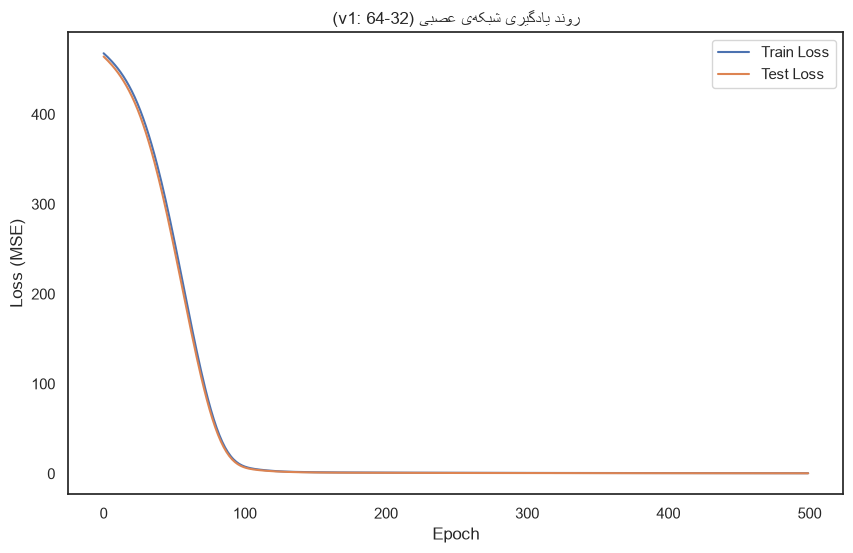

In [62]:
plt.figure(figsize=(10,6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('روند یادگیری شبکه‌ی عصبی (v1: 64-32)')
plt.legend()
plt.show()

In [63]:
n_epochs = 3000

torch.manual_seed(42)
model_v1 = HousePriceNN(X_train_t.shape[1])
optimizer = torch.optim.Adam(model_v1.parameters(), lr=0.001)

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    model_v1.train()
    optimizer.zero_grad()
    y_pred_train = model_v1(X_train_t)
    loss = criterion(y_pred_train, y_train_t)
    loss.backward()
    optimizer.step()

    model_v1.eval()
    with torch.no_grad():
        y_pred_test = model_v1(X_test_t)
        test_loss = criterion(y_pred_test, y_test_t)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if (epoch+1) % 300 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {loss.item():.4f} - Test Loss: {test_loss.item():.4f}")

Epoch 300/3000 - Train Loss: 0.7595 - Test Loss: 0.6009
Epoch 600/3000 - Train Loss: 0.3252 - Test Loss: 0.3111
Epoch 900/3000 - Train Loss: 0.1892 - Test Loss: 0.2207
Epoch 1200/3000 - Train Loss: 0.1506 - Test Loss: 0.1877
Epoch 1500/3000 - Train Loss: 0.1384 - Test Loss: 0.1753
Epoch 1800/3000 - Train Loss: 0.1328 - Test Loss: 0.1702
Epoch 2100/3000 - Train Loss: 0.1288 - Test Loss: 0.1678
Epoch 2400/3000 - Train Loss: 0.1261 - Test Loss: 0.1664
Epoch 2700/3000 - Train Loss: 0.1239 - Test Loss: 0.1666
Epoch 3000/3000 - Train Loss: 0.1221 - Test Loss: 0.1690


In [64]:
model_v1.eval()
with torch.no_grad():
    y_pred_test_nn = model_v1(X_test_t).numpy().flatten()

nn_test_r2 = r2_score(y_test_t.numpy().flatten(), y_pred_test_nn)
nn_test_rmse = np.sqrt(mean_squared_error(y_test_t.numpy().flatten(), y_pred_test_nn))

print("NN R2:", nn_test_r2)
print("NN RMSE:", nn_test_rmse)

NN R2: 0.8557056188583374
NN RMSE: 0.4110582333877373


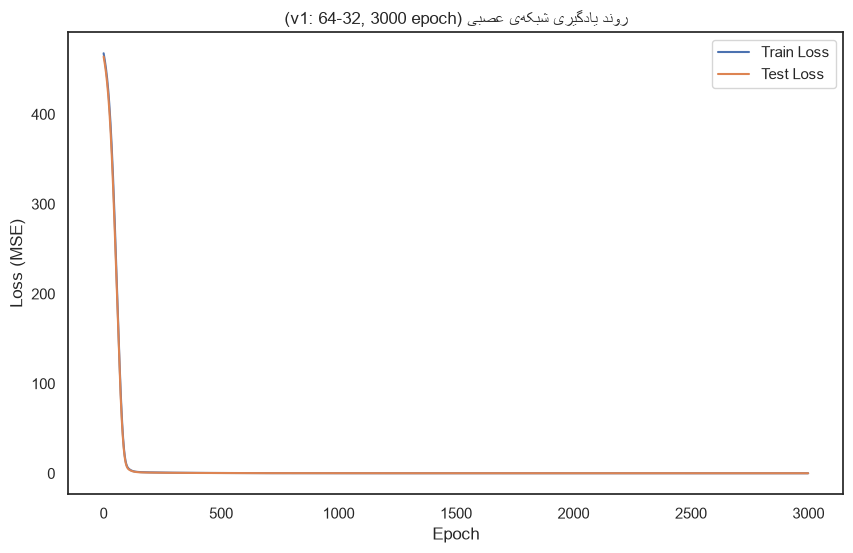

In [65]:
plt.figure(figsize=(10,6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('روند یادگیری شبکه‌ی عصبی (v1: 64-32, 3000 epoch)')
plt.legend()
plt.show()

In [67]:
class HousePriceNN_v2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model_v2 = HousePriceNN_v2(X_train_t.shape[1])
print(model_v2)

HousePriceNN_v2(
  (net): Sequential(
    (0): Linear(in_features=103, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [69]:
n_epochs = 3000

torch.manual_seed(42)
model_v2 = HousePriceNN_v2(X_train_t.shape[1])
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)

train_losses_v2 = []
test_losses_v2 = []

for epoch in range(n_epochs):
    model_v2.train()
    optimizer_v2.zero_grad()
    y_pred_train = model_v2(X_train_t)
    loss = criterion(y_pred_train, y_train_t)
    loss.backward()
    optimizer_v2.step()

    model_v2.eval()
    with torch.no_grad():
        y_pred_test = model_v2(X_test_t)
        test_loss = criterion(y_pred_test, y_test_t)

    train_losses_v2.append(loss.item())
    test_losses_v2.append(test_loss.item())

    if (epoch+1) % 300 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {loss.item():.4f} - Test Loss: {test_loss.item():.4f}")

Epoch 300/3000 - Train Loss: 8.0239 - Test Loss: 0.5100
Epoch 600/3000 - Train Loss: 6.7546 - Test Loss: 0.3501
Epoch 900/3000 - Train Loss: 5.4698 - Test Loss: 0.2939
Epoch 1200/3000 - Train Loss: 3.8349 - Test Loss: 0.2344
Epoch 1500/3000 - Train Loss: 3.2142 - Test Loss: 0.1865
Epoch 1800/3000 - Train Loss: 1.5946 - Test Loss: 3.3194
Epoch 2100/3000 - Train Loss: 1.2827 - Test Loss: 7.0900
Epoch 2400/3000 - Train Loss: 1.1630 - Test Loss: 9.0185
Epoch 2700/3000 - Train Loss: 1.0453 - Test Loss: 10.0170
Epoch 3000/3000 - Train Loss: 0.9445 - Test Loss: 10.0897


In [70]:
import copy

n_epochs = 3000

torch.manual_seed(42)
model_v2 = HousePriceNN_v2(X_train_t.shape[1])
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)

train_losses_v2 = []
test_losses_v2 = []
best_test_loss = float('inf')
best_model_state = None
best_epoch = 0

for epoch in range(n_epochs):
    model_v2.train()
    optimizer_v2.zero_grad()
    y_pred_train = model_v2(X_train_t)
    loss = criterion(y_pred_train, y_train_t)
    loss.backward()
    optimizer_v2.step()

    model_v2.eval()
    with torch.no_grad():
        y_pred_test = model_v2(X_test_t)
        test_loss = criterion(y_pred_test, y_test_t)

    train_losses_v2.append(loss.item())
    test_losses_v2.append(test_loss.item())

    if test_loss.item() < best_test_loss:
        best_test_loss = test_loss.item()
        best_model_state = copy.deepcopy(model_v2.state_dict())
        best_epoch = epoch + 1

    if (epoch+1) % 300 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {loss.item():.4f} - Test Loss: {test_loss.item():.4f}")

print(f"\nبهترین Epoch: {best_epoch} با Test Loss: {best_test_loss:.4f}")
model_v2.load_state_dict(best_model_state)

Epoch 300/3000 - Train Loss: 8.0239 - Test Loss: 0.5100
Epoch 600/3000 - Train Loss: 6.7546 - Test Loss: 0.3501
Epoch 900/3000 - Train Loss: 5.4698 - Test Loss: 0.2939
Epoch 1200/3000 - Train Loss: 3.8349 - Test Loss: 0.2344
Epoch 1500/3000 - Train Loss: 3.2142 - Test Loss: 0.1865
Epoch 1800/3000 - Train Loss: 1.5946 - Test Loss: 3.3194
Epoch 2100/3000 - Train Loss: 1.2827 - Test Loss: 7.0900
Epoch 2400/3000 - Train Loss: 1.1630 - Test Loss: 9.0185
Epoch 2700/3000 - Train Loss: 1.0453 - Test Loss: 10.0170
Epoch 3000/3000 - Train Loss: 0.9445 - Test Loss: 10.0897

بهترین Epoch: 1235 با Test Loss: 0.1585


<All keys matched successfully>

In [71]:
model_v2.eval()
with torch.no_grad():
    y_pred_test_nn2 = model_v2(X_test_t).numpy().flatten()

nn2_test_r2 = r2_score(y_test_t.numpy().flatten(), y_pred_test_nn2)
nn2_test_rmse = np.sqrt(mean_squared_error(y_test_t.numpy().flatten(), y_pred_test_nn2))

print("NN v2 R2:", nn2_test_r2)
print("NN v2 RMSE:", nn2_test_rmse)


NN v2 R2: 0.8646823167800903
NN v2 RMSE: 0.3980668531800626


In [73]:
nn_results = pd.DataFrame({
    'Training R2': [None, None],
    'Testing R2': [nn_test_r2, nn2_test_r2],
    'RMSE': [nn_test_rmse, nn2_test_rmse]
}, index=['NeuralNet_v1', 'NeuralNet_v2'])

models_score_full = pd.concat([models_score, nn_results])
models_score_full = models_score_full.sort_values('Testing R2', ascending=False)
print(models_score_full)

                 Training R2  Testing R2  RMSE
XGBoost                 0.93        0.91  0.33
Ridge                   0.86        0.88  0.37
LinearRegression        0.87        0.88  0.37
ElasticNet              0.86        0.88  0.38
Lasso                   0.85        0.87  0.39
NeuralNet_v2            None        0.86  0.40
RandomForest            0.95        0.86  0.40
NeuralNet_v1            None        0.86  0.41
DecisionTree            0.97        0.82  0.46
KNN                     0.99        0.74  0.55


In [76]:
!pip install wandb

Looking in indexes: https://mirror-pypi.runflare.com/simple
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [81]:
import wandb
wandb.login(key="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")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\novin\_netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [82]:
run = wandb.init(
    project="house-price-prediction",
    name="NN_v2_128-64-32_dropout",
    config={
        "architecture": "128-64-32",
        "dropout": 0.3,
        "epochs": 3000,
        "learning_rate": 0.001,
        "optimizer": "Adam"
    }
)

wandb: Currently logged in as: zahrarahgoshaa (zahrarahgoshaa-prohect) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in C:\Users\novin\PycharmProjects\JupyterProject10\wandb\run-20260811_155651-ithotczv
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run NN_v2_128-64-32_dropout
wandb:  View project at https://wandb.ai/zahrarahgoshaa-prohect/house-price-prediction
wandb:  View run at https://wandb.ai/zahrarahgoshaa-prohect/house-price-prediction/runs/ithotczv


In [83]:
import copy

n_epochs = 3000

torch.manual_seed(42)
model_v2 = HousePriceNN_v2(X_train_t.shape[1])
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)

train_losses_v2 = []
test_losses_v2 = []
best_test_loss = float('inf')
best_model_state = None
best_epoch = 0

for epoch in range(n_epochs):
    model_v2.train()
    optimizer_v2.zero_grad()
    y_pred_train = model_v2(X_train_t)
    loss = criterion(y_pred_train, y_train_t)
    loss.backward()
    optimizer_v2.step()

    model_v2.eval()
    with torch.no_grad():
        y_pred_test = model_v2(X_test_t)
        test_loss = criterion(y_pred_test, y_test_t)

    train_losses_v2.append(loss.item())
    test_losses_v2.append(test_loss.item())

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": loss.item(),
        "test_loss": test_loss.item()
    })

    if test_loss.item() < best_test_loss:
        best_test_loss = test_loss.item()
        best_model_state = copy.deepcopy(model_v2.state_dict())
        best_epoch = epoch + 1

    if (epoch+1) % 300 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {loss.item():.4f} - Test Loss: {test_loss.item():.4f}")

print(f"\nبهترین Epoch: {best_epoch} با Test Loss: {best_test_loss:.4f}")
model_v2.load_state_dict(best_model_state)

wandb.log({"best_epoch": best_epoch, "best_test_loss": best_test_loss})
wandb.finish()

Epoch 300/3000 - Train Loss: 8.0239 - Test Loss: 0.5100
Epoch 600/3000 - Train Loss: 6.7546 - Test Loss: 0.3501
Epoch 900/3000 - Train Loss: 5.4698 - Test Loss: 0.2939
Epoch 1200/3000 - Train Loss: 3.8349 - Test Loss: 0.2344
Epoch 1500/3000 - Train Loss: 3.2142 - Test Loss: 0.1865
Epoch 1800/3000 - Train Loss: 1.5946 - Test Loss: 3.3194
Epoch 2100/3000 - Train Loss: 1.2827 - Test Loss: 7.0900
Epoch 2400/3000 - Train Loss: 1.1630 - Test Loss: 9.0185
Epoch 2700/3000 - Train Loss: 1.0453 - Test Loss: 10.0170


wandb: updating run metadata


Epoch 3000/3000 - Train Loss: 0.9445 - Test Loss: 10.0897

بهترین Epoch: 1235 با Test Loss: 0.1585


wandb: uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 2633-3000, summary
wandb: 
wandb: Run history:
wandb:     best_epoch ▁
wandb: best_test_loss ▁
wandb:          epoch ▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
wandb:      test_loss ▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▂▂▃▄▅▅▇▇█████
wandb:     train_loss █▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:     best_epoch 1235
wandb: best_test_loss 0.15846
wandb:          epoch 3000
wandb:      test_loss 10.08969
wandb:     train_loss 0.94448
wandb: 
wandb:  View run NN_v2_128-64-32_dropout at: https://wandb.ai/zahrarahgoshaa-prohect/house-price-prediction/runs/ithotczv
wandb:  View project at: https://wandb.ai/zahrarahgoshaa-prohect/house-price-prediction
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: .\wandb\run-20260811_155651-ithotczv\logs


In [84]:
import joblib

torch.save(model_v2.state_dict(), 'house_price_model.pth')

joblib.dump(scaler, 'scaler.pkl')

feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

print("همه چیز ذخیره شد ✅")
print("تعداد فیچرها:", len(feature_columns))

همه چیز ذخیره شد ✅
تعداد فیچرها: 103


In [85]:
import os
print(os.getcwd())

C:\Users\novin\PycharmProjects\JupyterProject10
